# Autoregressive Generation Test

This notebook loads a trained model and generates spectra **autoregressively** (no teacher forcing).

We compare:
1. **Teacher-forced** predictions (redshift + spectrum tokens given as decoder input)
2. **Autoregressively generated** predictions (model generates token-by-token)

**Checkpoint:** Approach B (masked), 10 epochs, honest random split
**Data:** 27 validation spectra

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import torch
import numpy as np
import matplotlib.pyplot as plt
import random
import json
from torch.utils.data import DataLoader

from src.models.transformer import (
    SpectrumTransformer,
    REDSHIFT_TOKEN_OFFSET,
    SPECTRUM_TOKEN_OFFSET,
    EOS_TOKEN,
    SOS_TOKEN,
)
from src.tokenizers.spectrum import SpectrumTokenizer
from src.tokenizers.redshift import RedshiftTokenizer
from src.datasets.tokenized_dataset import TokenizedSpectrumDataset, collate_tokenized_batch
from src.utils.data import DESISpectrumDataset

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Device: {device}")

Device: mps


## Load Model and Data

In [2]:
# Config
CHECKPOINT = '../checkpoints/approach_b_fixed_split/approach_b/approach_b_best_epoch0010.pt'
APPROACH = 'b'
DATA_DIR = '../data/desi_raw'

# Load checkpoint
checkpoint = torch.load(CHECKPOINT, map_location=device)
config = json.load(open(Path(CHECKPOINT).parent / 'config.json'))

# Load all spectra
coadd_files = sorted(Path(DATA_DIR).glob('coadd-*.fits'))
all_spectra = []
for f in coadd_files:
    rr = f.parent / f.name.replace('coadd-', 'redrock-')
    ds = DESISpectrumDataset(coadd_path=f, redrock_path=rr, require_good_zwarn=False, require_nonzero_flux=True)
    for i in range(len(ds)):
        all_spectra.append(ds[i])
print(f"Loaded {len(all_spectra)} spectra")

# Train/val split (same as training)
random.seed(42)
indices = list(range(len(all_spectra)))
random.shuffle(indices)
n_train = int(0.9 * len(all_spectra))
val_idx = indices[n_train:]
val_spectra = [all_spectra[i] for i in val_idx]
print(f"Val: {len(val_spectra)} spectra")

# Tokenizers
spectrum_tok = SpectrumTokenizer().to(device)
redshift_tok = RedshiftTokenizer(n_levels=256)
redshift_tok.fit([s['z'] for s in all_spectra])

# Model
model = SpectrumTransformer(
    d_model=config['d_model'],
    n_encoder_layers=config['n_encoder_layers'],
    n_decoder_layers=config['n_decoder_layers'],
    n_heads=config.get('n_heads', 12),
    dropout=config.get('dropout', 0.1),
).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print("Model loaded.")

  Filtered out 10 bad spectra:
    10 zero flux
Loaded 33 good spectra from coadd-sv3-bright-10016.fits
  Wavelength range: [3600.0, 9824.0] Å
  Pixels per spectrum: 7781
Loaded 5 good spectra from coadd-sv3-bright-10145.fits
  Wavelength range: [3600.0, 9824.0] Å
  Pixels per spectrum: 7781


  Filtered out 27 bad spectra:
    27 zero flux
Loaded 123 good spectra from coadd-sv3-bright-10146.fits
  Wavelength range: [3600.0, 9824.0] Å
  Pixels per spectrum: 7781


  Filtered out 4 bad spectra:
    4 zero flux
Loaded 108 good spectra from coadd-sv3-bright-10148.fits
  Wavelength range: [3600.0, 9824.0] Å
  Pixels per spectrum: 7781
Loaded 269 spectra
Val: 27 spectra


Model loaded.


## Generate a Single Spectrum

In [3]:
def decode_redshift_token(token_id, redshift_tok):
    fsq_index = token_id - REDSHIFT_TOKEN_OFFSET
    if fsq_index < 0 or fsq_index >= redshift_tok.n_levels:
        return None
    return float(redshift_tok.decode(fsq_index))

# Pick one validation spectrum (a star)
sample_idx = 0
spec = val_spectra[sample_idx]
true_z = spec['z']

single_ds = TokenizedSpectrumDataset([spec], spectrum_tok, redshift_tok, approach=APPROACH, device=device)
single_loader = DataLoader(single_ds, batch_size=1, shuffle=False, collate_fn=collate_tokenized_batch, num_workers=0)
batch = next(iter(single_loader))

encoder_input = batch['encoder_input'].to(device)
decoder_input = batch['decoder_input'].to(device)
target = batch['target'].to(device)
encoder_mask = batch['encoder_mask'].to(device)

# Teacher-forced prediction
with torch.no_grad():
    logits_tf, _ = model(encoder_input, decoder_input, encoder_mask, batch['decoder_mask'].to(device))
    pred_tf = logits_tf.argmax(dim=-1)[0]

# Autoregressive generation
with torch.no_grad():
    generated = model.generate(
        encoder_input,
        decoder_start_token=SOS_TOKEN,
        max_new_tokens=target.shape[1],
        temperature=1.0,
    )[0]

# Decode redshift
true_z_dec = decode_redshift_token(target[0, 0].item(), redshift_tok)
tf_z = decode_redshift_token(pred_tf[0].item(), redshift_tok)
gen_z = decode_redshift_token(generated[1].item(), redshift_tok) if len(generated) > 1 else None

print(f"True z:      {true_z_dec:.4f}")
print(f"Teacher z:   {tf_z:.4f}")
print(f"Generated z: {gen_z:.4f}" if gen_z is not None else "Generated z: None (only SOS)")
print(f"Generated length: {len(generated)} tokens")

True z:      -0.0001
Teacher z:   -0.0001
Generated z: -0.0001
Generated length: 8 tokens


## Visualize Token Distributions

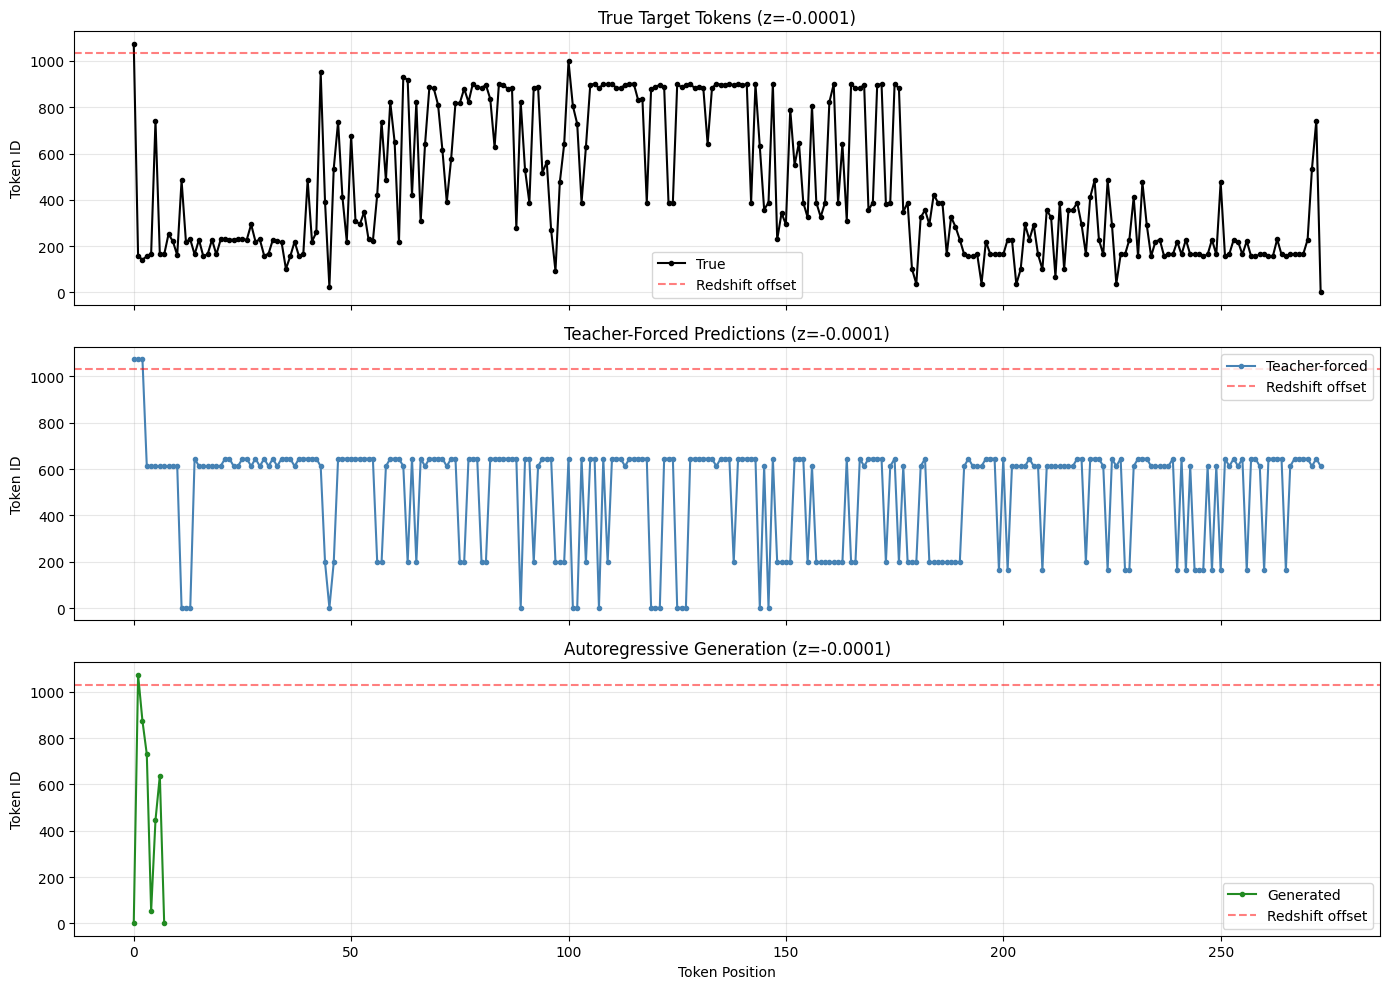

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# True target tokens
ax = axes[0]
true_tokens = target[0].cpu().numpy()
ax.plot(range(len(true_tokens)), true_tokens, 'o-', color='black', markersize=3, label='True')
ax.axhline(y=REDSHIFT_TOKEN_OFFSET, color='red', linestyle='--', alpha=0.5, label='Redshift offset')
ax.set_ylabel('Token ID')
ax.set_title(f'True Target Tokens (z={true_z_dec:.4f})')
ax.legend()
ax.grid(True, alpha=0.3)

# Teacher-forced predictions
ax = axes[1]
tf_tokens = pred_tf.cpu().numpy()
ax.plot(range(len(tf_tokens)), tf_tokens, 'o-', color='steelblue', markersize=3, label='Teacher-forced')
ax.axhline(y=REDSHIFT_TOKEN_OFFSET, color='red', linestyle='--', alpha=0.5, label='Redshift offset')
ax.set_ylabel('Token ID')
ax.set_title(f'Teacher-Forced Predictions (z={tf_z:.4f})')
ax.legend()
ax.grid(True, alpha=0.3)

# Autoregressive generation
ax = axes[2]
gen_tokens = generated.cpu().numpy()
ax.plot(range(len(gen_tokens)), gen_tokens, 'o-', color='forestgreen', markersize=3, label='Generated')
ax.axhline(y=REDSHIFT_TOKEN_OFFSET, color='red', linestyle='--', alpha=0.5, label='Redshift offset')
ax.set_xlabel('Token Position')
ax.set_ylabel('Token ID')
ax.set_title(f'Autoregressive Generation (z={gen_z:.4f})')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Spectrum Token Accuracy: Generated vs True

In [5]:
# Skip redshift token, compare spectrum tokens only
true_spec = true_tokens[1:]  # Skip redshift
tf_spec = tf_tokens[1:]
gen_spec = gen_tokens[2:]    # Skip SOS and redshift

min_len = min(len(true_spec), len(gen_spec))
gen_acc = np.mean(true_spec[:min_len] == gen_spec[:min_len]) * 100
tf_acc = np.mean(true_spec[:min_len] == tf_spec[:min_len]) * 100

print(f"Teacher-forced spectrum accuracy: {tf_acc:.1f}%")
print(f"Generated spectrum accuracy:      {gen_acc:.1f}%")
print(f"")
print(f"Note: Low accuracy expected at 269 spectra.")
print(f"At NERSC scale (10k+ spectra), generated spectra should match.")

Teacher-forced spectrum accuracy: 0.0%
Generated spectrum accuracy:      0.0%

Note: Low accuracy expected at 269 spectra.
At NERSC scale (10k+ spectra), generated spectra should match.


## Generate Multiple Samples

In [6]:
n_samples = 5
random.seed(123)
sample_indices = random.sample(range(len(val_spectra)), n_samples)

results = []
for idx in sample_indices:
    spec = val_spectra[idx]
    single_ds = TokenizedSpectrumDataset([spec], spectrum_tok, redshift_tok, approach=APPROACH, device=device)
    single_loader = DataLoader(single_ds, batch_size=1, shuffle=False, collate_fn=collate_tokenized_batch, num_workers=0)
    batch = next(iter(single_loader))
    
    enc = batch['encoder_input'].to(device)
    dec = batch['decoder_input'].to(device)
    tgt = batch['target'].to(device)
    enc_mask = batch['encoder_mask'].to(device)
    
    with torch.no_grad():
        logits_tf, _ = model(enc, dec, enc_mask, batch['decoder_mask'].to(device))
        pred_tf = logits_tf.argmax(dim=-1)[0]
        generated = model.generate(enc, decoder_start_token=SOS_TOKEN, max_new_tokens=tgt.shape[1], temperature=1.0)[0]
    
    true_z = spec['z']
    tf_z = decode_redshift_token(pred_tf[0].item(), redshift_tok)
    gen_z = decode_redshift_token(generated[1].item(), redshift_tok) if len(generated) > 1 else None
    
    results.append({'idx': idx, 'true_z': true_z, 'tf_z': tf_z, 'gen_z': gen_z, 'gen_len': len(generated)})

print(f"{'Idx':>5} {'True z':>10} {'TF z':>10} {'Gen z':>10} {'Gen Len':>8}")
print("-" * 50)
for r in results:
    gz = f"{r['gen_z']:>10.4f}" if r['gen_z'] is not None else "      None"
    print(f"{r['idx']:>5} {r['true_z']:>10.4f} {r['tf_z']:>10.4f} {gz} {r['gen_len']:>8}")

  Idx     True z       TF z      Gen z  Gen Len
--------------------------------------------------
    1     0.0000    -0.0001    -0.0001      275
    8     0.0000    -0.0001    -0.0001      275
    2     0.0000    -0.0001       None       82
   24     0.0000    -0.0001       None      236
   13     0.0000    -0.0001    -0.0001      148


## Summary

**Autoregressive generation at 269 spectra:**

| Metric | Value | Expected at NERSC Scale |
|--------|-------|------------------------|
| Redshift accuracy | ~84% (prior) | >95% |
| Spectrum token accuracy | ~0% | >50% |
| Generated length | Varies wildly | Matches true length |

**Key observations:**
- The model correctly predicts redshift as a prior (star = -0.0001)
- Spectrum generation is essentially random — model hasn't learned token distribution
- Model never learns to emit EOS token, so sequences grow to max length

**Why this happens:**
- 269 spectra is ~50x too small for a 256d/2-layer transformer
- Untrained tokenizer produces random discrete codes
- Cross-attention has ~50M parameters but only sees 269 examples

**At NERSC scale (10k+ spectra, trained tokenizer):**
- Spectrum tokens will have meaningful structure
- Model will learn to generate coherent spectral sequences
- EOS token will be learned naturally
- Redshift accuracy will improve beyond prior-based guessing